# Notebook 1 — CNN simples + LIME em log-mel

## Objetivo

Este notebook cria o frontend principal do experimento em um domínio típico de Audio XAI:

$$
x
\rightarrow
\mathrm{STFT}
\rightarrow
|\mathrm{STFT}|^2
\rightarrow
\mathrm{Mel}
\rightarrow
\log(1+\mathrm{Mel})
\rightarrow
\mathrm{CNN}.
$$

O explicador LIME atua diretamente sobre o **log-mel que a CNN recebe**.

Ao final salvamos:

- CNN treinada;
- banco de filtros mel;
- pseudoinversa mel;
- áudios de teste;
- classes alvo;
- rankings LIME.

O objetivo é uma demonstração simples.

## 1. Dependências

A instalação usa o mesmo Python do kernel atual.


In [1]:
import sys
import subprocess

packages = [
    "datasets>=4.0",
    "soundfile",
    "scipy",
    "scikit-learn",
    "pandas",
    "matplotlib"
]

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", *packages]
)

print("Python:", sys.executable)


Python: /home/las/Bioacustica - Periodico/.venv/bin/python


In [2]:
from pathlib import Path
import io
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf

from scipy.signal import resample_poly
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from datasets import load_dataset, Audio

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)


Device: cuda


/home/las/Bioacustica - Periodico/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuração acústica

Usamos:

$$
f_s = 16000\ \mathrm{Hz},
$$

$$
N_{\mathrm{FFT}} = 512,
$$

$$
H = 256,
$$

e 64 bandas mel.

O espectrograma de potência é:

$$
P = |X|^2.
$$

A projeção mel é:

$$
M = HP,
$$

onde $H$ é o banco de filtros mel.

A entrada da CNN é:

$$
L = \log(1+M).
$$


In [3]:
DATASET_NAME = "DynamicSuperb/BirdSoundDetection_Warblrb10k"

SR = 16000
DURATION = 10.0
N_SAMPLES = int(SR * DURATION)

N_FFT = 512
HOP = 256

N_MELS = 64
FMIN = 0.0
FMAX = SR / 2

GRID_F = 6
GRID_T = 8

# Mantemos o protótipo pequeno para o Notebook 2 não ficar impraticável.
MAX_EXAMPLES = 200

ART = Path("artifacts_logmel")
ART.mkdir(exist_ok=True)

print("Artifacts:", ART.resolve())


Artifacts: /home/las/Bioacustica - Periodico/artifacts_logmel


## 3. Dataset

Usamos `Audio(decode=False)` para evitar TorchCodec.  
O áudio é lido manualmente com `soundfile`.


In [4]:
ds = load_dataset(
    DATASET_NAME,
    split="test"
)

ds = ds.cast_column(
    "audio",
    Audio(decode=False)
)

if MAX_EXAMPLES is not None and len(ds) > MAX_EXAMPLES:
    ds = (
        ds
        .shuffle(seed=SEED)
        .select(range(MAX_EXAMPLES))
    )

print(ds)
print("Exemplos usados:", len(ds))
print("Features:", ds.features)


Dataset({
    features: ['file', 'audio', 'label', 'instruction'],
    num_rows: 200
})
Exemplos usados: 200
Features: {'file': Value('string'), 'audio': Audio(sampling_rate=None, decode=False, num_channels=None, stream_index=None), 'label': Value('string'), 'instruction': Value('string')}


In [6]:
label_feature = ds.features["label"]

def label_to_binary(value):

    if isinstance(value, str):
        name = value
    elif hasattr(label_feature, "int2str"):
        name = label_feature.int2str(int(value))
    else:
        name = str(value)

    text = str(name).strip().lower()

    if text == "presence":
        return 1

    if text == "absence":
        return 0

    raise ValueError(
        f"Rótulo não reconhecido: {value!r} / {name!r}"
    )

    # Testa negativos primeiro para evitar "bird" dentro de "no bird".
    for term in negative_terms:
        if text == term or term in text:
            return 0

    for term in positive_terms:
        if text == term or term in text:
            return 1

    # Fallback para rótulo inteiro 0/1.
    try:
        value_int = int(value)
        if value_int in (0, 1):
            return value_int
    except Exception:
        pass

    raise ValueError(f"Rótulo não reconhecido: {value!r} / {name!r}")


def read_audio(item):
    audio = item["audio"]

    if audio.get("bytes") is not None:
        source = io.BytesIO(audio["bytes"])
    else:
        source = audio["path"]

    wave, sr = sf.read(
        source,
        dtype="float32",
        always_2d=False
    )

    if wave.ndim == 2:
        wave = wave.mean(axis=1)

    if sr != SR:
        g = math.gcd(int(sr), SR)

        wave = resample_poly(
            wave,
            SR // g,
            int(sr) // g
        ).astype(np.float32)

    if len(wave) < N_SAMPLES:
        wave = np.pad(
            wave,
            (0, N_SAMPLES - len(wave))
        )
    else:
        wave = wave[:N_SAMPLES]

    return wave.astype(np.float32)


waves = []
labels = []

for i, item in enumerate(ds):
    waves.append(read_audio(item))
    labels.append(label_to_binary(item["label"]))

    if (i + 1) % 25 == 0:
        print(f"{i + 1}/{len(ds)}")

waveforms = np.stack(waves)
labels = np.asarray(labels, dtype=np.int64)

print("waveforms:", waveforms.shape)
print("labels:", np.bincount(labels))


25/200
50/200
75/200
100/200
125/200
150/200
175/200
200/200
waveforms: (200, 160000)
labels: [ 50 150]


## 4. Banco de filtros mel

Para evitar uma dependência extra, construímos explicitamente um banco triangular na escala mel HTK:

$$
m(f)=2595\log_{10}\left(1+\frac{f}{700}\right).
$$

Esse banco é fixo e será salvo para o Notebook 2.


In [7]:
def hz_to_mel(f):
    f = np.asarray(f, dtype=np.float64)
    return 2595.0 * np.log10(1.0 + f / 700.0)


def mel_to_hz(m):
    m = np.asarray(m, dtype=np.float64)
    return 700.0 * (10.0 ** (m / 2595.0) - 1.0)


def make_mel_filterbank(
    sr,
    n_fft,
    n_mels,
    fmin,
    fmax
):
    freqs = np.linspace(
        0.0,
        sr / 2,
        n_fft // 2 + 1
    )

    mel_points = np.linspace(
        hz_to_mel(fmin),
        hz_to_mel(fmax),
        n_mels + 2
    )

    hz_points = mel_to_hz(mel_points)

    bank = np.zeros(
        (n_mels, len(freqs)),
        dtype=np.float32
    )

    for m in range(1, n_mels + 1):
        left = hz_points[m - 1]
        center = hz_points[m]
        right = hz_points[m + 1]

        left_mask = (
            (freqs >= left)
            &
            (freqs <= center)
        )

        right_mask = (
            (freqs >= center)
            &
            (freqs <= right)
        )

        if center > left:
            bank[m - 1, left_mask] = (
                (freqs[left_mask] - left)
                /
                (center - left)
            )

        if right > center:
            bank[m - 1, right_mask] = (
                (right - freqs[right_mask])
                /
                (right - center)
            )

    return bank


mel_filterbank = make_mel_filterbank(
    SR,
    N_FFT,
    N_MELS,
    FMIN,
    FMAX
)

# Inversão linear de mínimos quadrados usada no Notebook 2.
mel_pinv = np.linalg.pinv(
    mel_filterbank
).astype(np.float32)

np.save(
    ART / "mel_filterbank.npy",
    mel_filterbank
)

np.save(
    ART / "mel_pinv.npy",
    mel_pinv
)

print("Mel filterbank:", mel_filterbank.shape)
print("Mel pseudoinverse:", mel_pinv.shape)


Mel filterbank: (64, 257)
Mel pseudoinverse: (257, 64)


## 5. Frontend log-mel

Para cada áudio:

$$
X = \mathrm{STFT}(x),
$$

$$
P = |X|^2,
$$

$$
M = HP,
$$

$$
L = \log(1+M).
$$


In [8]:
window = torch.hann_window(N_FFT)

mel_bank_t = torch.from_numpy(
    mel_filterbank
).float()


def waveform_to_logmel(wave):
    if isinstance(wave, np.ndarray):
        x = torch.from_numpy(
            wave.astype(np.float32)
        )
    else:
        x = wave.detach().float().cpu()

    Z = torch.stft(
        x,
        n_fft=N_FFT,
        hop_length=HOP,
        window=window,
        return_complex=True
    )

    power = torch.abs(Z) ** 2

    mel = mel_bank_t @ power

    logmel = torch.log1p(
        torch.clamp(mel, min=0.0)
    )

    return logmel


logmels = torch.stack([
    waveform_to_logmel(w)
    for w in waveforms
])

print("logmels:", tuple(logmels.shape))


logmels: (200, 64, 626)


## 6. Split local e CNN

O dataset é usado aqui apenas para uma demonstração metodológica.  
O split 80/20 é local e não deve ser interpretado como protocolo oficial do dataset.


In [9]:
indices = np.arange(len(labels))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

X_train = logmels[train_idx].unsqueeze(1)
X_test = logmels[test_idx].unsqueeze(1)

y_train = torch.from_numpy(
    labels[train_idx]
).long()

y_test = torch.from_numpy(
    labels[test_idx]
).long()

print("Train:", len(train_idx))
print("Test:", len(test_idx))


Train: 160
Test: 40


In [10]:
class TinyBirdCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(16, 2)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


model = TinyBirdCNN().to(DEVICE)

class_counts = np.bincount(
    y_train.numpy(),
    minlength=2
)

class_weights = (
    len(y_train)
    /
    (2.0 * np.maximum(class_counts, 1))
)

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=DEVICE
    )
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

train_loader = DataLoader(
    TensorDataset(
        X_train,
        y_train
    ),
    batch_size=16,
    shuffle=True
)

EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(
            logits,
            yb
        )

        loss.backward()
        optimizer.step()

        running_loss += float(loss.item()) * len(xb)

    print(
        f"epoch {epoch + 1:02d} "
        f"loss={running_loss / len(train_idx):.4f}"
    )


epoch 01 loss=0.6887
epoch 02 loss=0.6810
epoch 03 loss=0.6835
epoch 04 loss=0.6827
epoch 05 loss=0.6808
epoch 06 loss=0.6802
epoch 07 loss=0.6732
epoch 08 loss=0.6773
epoch 09 loss=0.6736
epoch 10 loss=0.6736
epoch 11 loss=0.6729
epoch 12 loss=0.6703
epoch 13 loss=0.6700
epoch 14 loss=0.6682
epoch 15 loss=0.6671


In [11]:
model.eval()

with torch.no_grad():
    test_logits = model(
        X_test.to(DEVICE)
    ).cpu()

test_probs = torch.softmax(
    test_logits,
    dim=1
)

test_preds = test_probs.argmax(
    dim=1
).numpy()

test_accuracy = accuracy_score(
    y_test.numpy(),
    test_preds
)

print("Local test accuracy:", test_accuracy)


Local test accuracy: 0.525


## 7. LIME simples no log-mel

Dividimos o log-mel em uma grade de 6 × 8 regiões.

Cada perturbação LIME liga ou desliga regiões diretamente no domínio que a CNN recebe.

A regressão local Ridge produz um coeficiente por região.  
Ordenamos os coeficientes em ordem decrescente para obter o ranking.


In [12]:
def make_regions(shape):
    freq_parts = np.array_split(
        np.arange(shape[0]),
        GRID_F
    )

    time_parts = np.array_split(
        np.arange(shape[1]),
        GRID_T
    )

    regions = []

    for f_idx in freq_parts:
        for t_idx in time_parts:
            regions.append(
                (f_idx, t_idx)
            )

    return regions


def apply_region_mask(
    logmel,
    mask
):
    out = logmel.clone()

    regions = make_regions(
        logmel.shape
    )

    for region_id, keep in enumerate(mask):
        if keep == 0:
            f_idx, t_idx = regions[region_id]

            f_idx = torch.as_tensor(
                f_idx,
                dtype=torch.long
            )

            t_idx = torch.as_tensor(
                t_idx,
                dtype=torch.long
            )

            out[
                f_idx[:, None],
                t_idx[None, :]
            ] = 0.0

    return out


def lime_explain(
    logmel,
    target_class,
    n_masks=300,
    seed=42
):
    rng = np.random.default_rng(seed)

    n_regions = GRID_F * GRID_T

    masks = rng.integers(
        0,
        2,
        size=(n_masks, n_regions)
    )

    masks[0] = 1

    batch = torch.stack([
        apply_region_mask(
            logmel,
            mask
        )
        for mask in masks
    ]).unsqueeze(1)

    outputs = []

    model.eval()

    with torch.no_grad():
        for start in range(
            0,
            len(batch),
            64
        ):
            xb = batch[
                start:start + 64
            ].to(DEVICE)

            probs = torch.softmax(
                model(xb),
                dim=1
            )[:, int(target_class)]

            outputs.append(
                probs.cpu().numpy()
            )

    y = np.concatenate(outputs)

    fraction_removed = (
        1.0
        -
        masks.mean(axis=1)
    )

    weights = np.exp(
        -4.0 * fraction_removed
    )

    reg = Ridge(
        alpha=1.0
    )

    reg.fit(
        masks,
        y,
        sample_weight=weights
    )

    coefficients = reg.coef_.astype(
        np.float32
    )

    ranking = np.argsort(
        -coefficients
    ).astype(np.int64)

    return coefficients, ranking


## 8. Explicar as amostras de teste


In [13]:
test_waveforms = waveforms[test_idx]
test_labels = labels[test_idx]
test_logmels = logmels[test_idx]

target_classes = test_preds.astype(
    np.int64
)

lime_coefficients = []
lime_rankings = []

for i in range(len(test_idx)):
    coefficients, ranking = lime_explain(
        test_logmels[i],
        target_classes[i],
        n_masks=300,
        seed=SEED + i
    )

    lime_coefficients.append(
        coefficients
    )

    lime_rankings.append(
        ranking
    )

    print(
        f"{i + 1:03d}/{len(test_idx)}"
    )

lime_coefficients = np.stack(
    lime_coefficients
)

lime_rankings = np.stack(
    lime_rankings
)

print("LIME coefficients:", lime_coefficients.shape)
print("LIME rankings:", lime_rankings.shape)


001/40
002/40
003/40
004/40
005/40
006/40
007/40
008/40
009/40
010/40
011/40
012/40
013/40
014/40
015/40
016/40
017/40
018/40
019/40
020/40
021/40
022/40
023/40
024/40
025/40
026/40
027/40
028/40
029/40
030/40
031/40
032/40
033/40
034/40
035/40
036/40
037/40
038/40
039/40
040/40
LIME coefficients: (40, 48)
LIME rankings: (40, 48)


## 9. Visualizar um exemplo


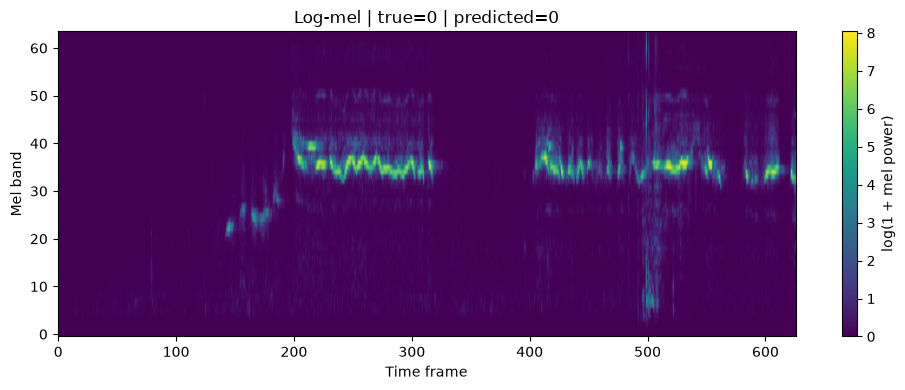

Top 10 LIME regions: [ 1  5  3 45 15 40  4 25 41 44]


In [14]:
EXAMPLE = 0

plt.figure(figsize=(10, 4))

plt.imshow(
    test_logmels[EXAMPLE].numpy(),
    origin="lower",
    aspect="auto"
)

plt.xlabel("Time frame")
plt.ylabel("Mel band")
plt.title(
    f"Log-mel | true={test_labels[EXAMPLE]} "
    f"| predicted={target_classes[EXAMPLE]}"
)

plt.colorbar(
    label="log(1 + mel power)"
)

plt.tight_layout()
plt.show()

print(
    "Top 10 LIME regions:",
    lime_rankings[EXAMPLE][:10]
)


## 10. Salvar artefatos


In [15]:
torch.save(
    model.state_dict(),
    ART / "tiny_bird_cnn_logmel.pt"
)

config = {
    "dataset": DATASET_NAME,
    "sr": SR,
    "duration": DURATION,
    "n_samples": N_SAMPLES,
    "n_fft": N_FFT,
    "hop": HOP,
    "n_mels": N_MELS,
    "fmin": FMIN,
    "fmax": FMAX,
    "mel_scale": "HTK_triangular",
    "mel_input": "power",
    "log_compression": "log1p",
    "grid_f": GRID_F,
    "grid_t": GRID_T,
    "seed": SEED,
    "max_examples": MAX_EXAMPLES
}

(
    ART / "config_logmel.json"
).write_text(
    json.dumps(
        config,
        indent=2
    )
)

np.savez_compressed(
    ART / "test_data_and_lime_logmel.npz",
    waveforms=test_waveforms.astype(
        np.float32
    ),
    labels=test_labels.astype(
        np.int64
    ),
    predictions=test_preds.astype(
        np.int64
    ),
    probabilities=test_probs.numpy().astype(
        np.float32
    ),
    target_classes=target_classes,
    lime_coefficients=lime_coefficients,
    lime_rankings=lime_rankings,
    original_indices=test_idx.astype(
        np.int64
    )
)

print("Notebook 1 concluído.")
print("Artifacts:", ART.resolve())


Notebook 1 concluído.
Artifacts: /home/las/Bioacustica - Periodico/artifacts_logmel


# Saída conceitual

O objeto explicado agora é realmente o log-mel:

$$
L
=
\log\left(1 + H|\mathrm{STFT}(x)|^2\right).
$$

O Notebook 2 partirá de uma perturbação em $L$ e terá de realizar a cadeia:

$$
\widetilde{L}
\rightarrow
\widetilde{M}
\rightarrow
\widetilde{P}
\rightarrow
\widetilde{A}
\rightarrow
\widetilde{x}.
$$
